In [22]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statistics as stat


In [44]:
df1 = pd.read_csv('SM_1_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
df2 = pd.read_csv('SM_2_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
df3 = pd.read_csv('SM_3_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
df5 = pd.read_csv('SM_5_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
df6 = pd.read_csv('SM_6_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")

dfs = [df1, df2, df3, df5, df6]
combined_df = pd.concat(dfs, ignore_index=True)
for i, row in combined_df.iterrows():
    if i < 59161:
        combined_df.at[i, "df1"] = 1
        combined_df.at[i, "df2"] = 0
        combined_df.at[i, "df3"] = 0
        combined_df.at[i, "df5"] = 0
        combined_df.at[i, "df6"] = 0
    elif i < 59161*2:
        combined_df.at[i, "df1"] = 0
        combined_df.at[i, "df2"] = 1
        combined_df.at[i, "df3"] = 0
        combined_df.at[i, "df5"] = 0
        combined_df.at[i, "df6"] = 0
    elif i < 59161*3:
        combined_df.at[i, "df1"] = 0
        combined_df.at[i, "df2"] = 0
        combined_df.at[i, "df3"] = 1
        combined_df.at[i, "df5"] = 0
        combined_df.at[i, "df6"] = 0
    elif i < 59161*3:
        combined_df.at[i, "df1"] = 0
        combined_df.at[i, "df2"] = 0
        combined_df.at[i, "df3"] = 0
        combined_df.at[i, "df5"] = 1
        combined_df.at[i, "df6"] = 0
    else:
        combined_df.at[i, "df1"] = 0
        combined_df.at[i, "df2"] = 0
        combined_df.at[i, "df3"] = 0
        combined_df.at[i, "df5"] = 0
        combined_df.at[i, "df6"] = 1
        
# combined_df.to_csv('file.csv', index=True)
print(sum(combined_df["df1"]) + sum(combined_df["df2"]) + sum(combined_df["df3"]) + sum(combined_df["df5"]) + sum(combined_df["df6"]))

295805.0


Initially, when solving for the linear model $y_{T50}=\beta_0 + \beta_1x_{T5} + \beta_2x_{T10} + \beta_3x_{T20} + \epsilon$, or similarly for $SWC$, the issue arised that the model seemed extremely noisy, especially when compared to $T20$ within the fourth station, or $T50$ from other stations. To correct this, the model was extropolated to correct for categorical differenced of each station, hence the binary assignment of the respective data point. So, the above corrects for this as now it demonstrates $y_{T50}=\beta_0 + \beta_1x_{T5} + \beta_2x_{T10} + \beta_3x_{T20} + \gamma_4k_1 + \gamma_5k_2 + \gamma_6k_3 + \gamma_7k_6 + \epsilon$ such that $k_i \in \{0,1\}$ for $i$ being the relative station/dataframe. For multicollinearity reasons, the fifth station dummy was dropped.

In [50]:
combined_df = combined_df.dropna(subset=["SWC_5","SWC_10","SWC_20","SWC_50","T_5","T_10","T_20","T_50"])
print(combined_df)


        Ppt  SWC_5  SWC_10  SWC_20  SWC_50    T_5   T_10   T_20   T_50  Flag  \
0       0.0  0.139   0.178   0.148   0.152   2.81   4.40   5.77  10.57     3   
1       0.0  0.139   0.178   0.148   0.152   2.86   4.38   5.71  10.51     3   
2       0.0  0.139   0.178   0.148   0.152   2.89   4.35   5.66  10.47     3   
3       0.0  0.139   0.178   0.148   0.152   2.90   4.33   5.62  10.41     3   
4       0.0  0.139   0.178   0.148   0.152   2.96   4.32   5.59  10.36     3   
...     ...    ...     ...     ...     ...    ...    ...    ...    ...   ...   
295800  0.0  0.162   0.160   0.162   0.101  28.76  29.05  28.94  27.89     3   
295801  0.0  0.162   0.160   0.161   0.101  28.24  28.61  28.75  27.98     3   
295802  0.0  0.162   0.159   0.161   0.101  27.80  28.21  28.53  28.05     3   
295803  0.0  0.162   0.159   0.160   0.101  27.44  27.87  28.30  28.10     3   
295804  0.0  0.161   0.159   0.160   0.101  27.15  27.60  28.08  28.15     3   

        df1  df2  df3  df5  df6  
0    

In [51]:
nan_mask = combined_df.isna() # Just to confirm there are no NaNs when running the model
nan_counts = nan_mask.sum()
print(nan_counts[nan_counts > 0])

Series([], dtype: int64)


In [67]:
X = combined_df[['T_5', 'T_10', 'T_20', 'df1', 'df2', 'df3', 'df6']]
# X = combined_df[['T_5', 'T_10', 'T_20']]
y = combined_df['T_50']

model = LinearRegression()

model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 1.21111566e+00 -2.90022738e+00  2.56383043e+00  8.87006910e-02
 -7.13899939e-02  2.75489076e-03 -2.00655879e-02]
Intercept: 2.7239303840109272


Even adjusting for categorical differences, the coefficients still relatively remained the same and did not change very much. Hence, the simulated data for station 4 still seems extremely noisy, as visualized below. 

In [58]:
df4 = pd.read_csv('SM_4_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")

for i, row in df4.iterrows():
    df4.at[i, "T_50"] = row['T_5']*model.coef_[0] + row['T_10']*model.coef_[1] + row['T_20']*model.coef_[2] + model.intercept_
    
print(df4)

                     Ppt  SWC_5  SWC_10  SWC_20  SWC_50    T_5   T_10   T_20  \
Date                                                                           
2015-01-01 00:00:00  0.0  0.232   0.253   0.199     NaN   2.60   4.05   8.15   
2015-01-01 01:00:00  0.0  0.232   0.253   0.199     NaN   2.60   4.01   8.08   
2015-01-01 02:00:00  0.0  0.231   0.253   0.199     NaN   2.59   3.97   8.03   
2015-01-01 03:00:00  0.0  0.232   0.254   0.199     NaN   2.61   3.94   7.95   
2015-01-01 04:00:00  0.0  0.232   0.254   0.199     NaN   2.64   3.93   7.90   
...                  ...    ...     ...     ...     ...    ...    ...    ...   
2021-09-30 20:00:00  0.0  0.280   0.293   0.232     NaN  25.79  26.55  26.04   
2021-09-30 21:00:00  0.0  0.279   0.292   0.232     NaN  25.29  26.14  26.11   
2021-09-30 22:00:00  0.0  0.278   0.292   0.231     NaN  24.91  25.80  26.14   
2021-09-30 23:00:00  0.0  0.277   0.291   0.231     NaN  24.53  25.49  26.12   
2021-10-01 00:00:00  0.0  0.276   0.290 

In [8]:
# df4 = pd.read_csv('SM_4_filled.dat', sep=",", parse_dates=["Date"], index_col="Date")
# for val in list(df4.columns.values):
#     if df4[val].isnull().values.any():
#         print(val)
        
# print()
# nan_mask = df4.isna()
# nan_counts = nan_mask.sum()
# print(nan_counts[nan_counts > 0])

In [9]:
A = combined_df[['SWC_5', 'SWC_10', 'SWC_20']]
B = combined_df['SWC_50']

new_model = LinearRegression()

new_model.fit(A, B)

print("Coefficients:", new_model.coef_)
print("Intercept:", new_model.intercept_)

for i, row in df4.iterrows():
    df4.at[i, "SWC_50"] = row['SWC_5']*new_model.coef_[0] + row['SWC_10']*new_model.coef_[1] + row['SWC_20']*new_model.coef_[2] + new_model.intercept_  

print(df4)

Coefficients: [ 0.74823341 -2.11916282  2.46351708]
Intercept: -0.003379138369209833
                     Ppt  SWC_5  SWC_10  SWC_20    SWC_50    T_5   T_10  \
Date                                                                      
2015-01-01 00:00:00  0.0  0.232   0.253   0.199  0.124303   2.60   4.05   
2015-01-01 01:00:00  0.0  0.232   0.253   0.199  0.124303   2.60   4.01   
2015-01-01 02:00:00  0.0  0.231   0.253   0.199  0.123554   2.59   3.97   
2015-01-01 03:00:00  0.0  0.232   0.254   0.199  0.122184   2.61   3.94   
2015-01-01 04:00:00  0.0  0.232   0.254   0.199  0.122184   2.64   3.93   
...                  ...    ...     ...     ...       ...    ...    ...   
2021-09-30 20:00:00  0.0  0.280   0.293   0.232  0.156747  25.79  26.55   
2021-09-30 21:00:00  0.0  0.279   0.292   0.232  0.158118  25.29  26.14   
2021-09-30 22:00:00  0.0  0.278   0.292   0.231  0.154907  24.91  25.80   
2021-09-30 23:00:00  0.0  0.277   0.291   0.231  0.156278  24.53  25.49   
2021-10-01 00:0

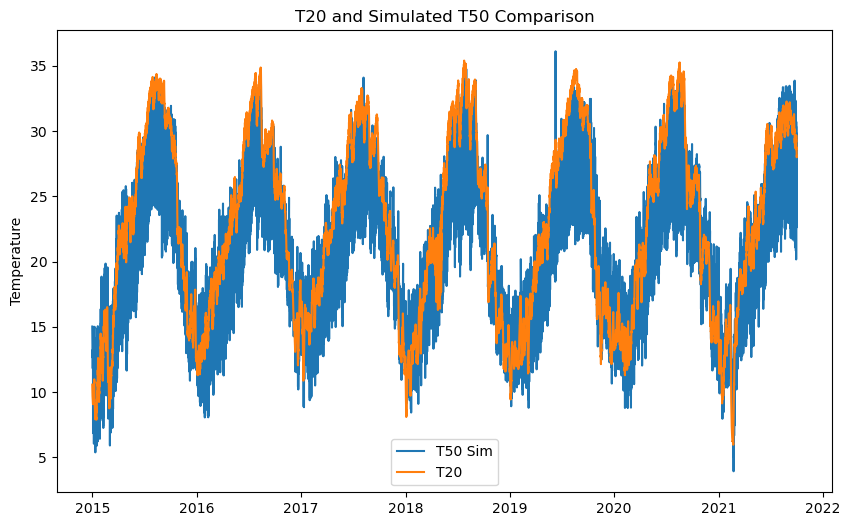

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(df4['T_50'], label='T50 Sim')
plt.plot(df1['T_50'], label='T20')

plt.ylabel('Temperature')
plt.title('T20 and Simulated T50 Comparison')

plt.legend()
plt.show()

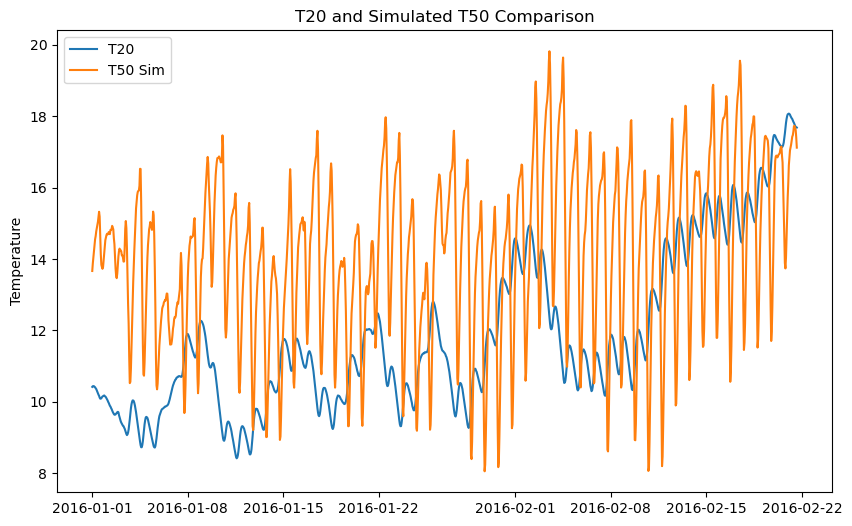

In [65]:
df4_sliced = df4[8760:10000]
plt.figure(figsize=(10, 6))
plt.plot(df4_sliced['T_20'], label='T20')
plt.plot(df4_sliced['T_50'], label='T50 Sim')

plt.ylabel('Temperature')
plt.title('T20 and Simulated T50 Comparison')

plt.legend()
plt.show()

Even after correcting the MLR with binary adjustments, by slicing and looking at closer segments of time, it seems the simulated data is extremely noisy. I note this because I am not sure if this will have any direct impact on the use of this data in the ML models.

In [71]:
df1["diff"] = df1["T_20"] - df1["T_50"]
print(df1["diff"].mean(), df1["diff"].max() - df1["diff"].min())

df2["diff"] = df2["T_20"] - df2["T_50"]
print(df2["diff"].mean(), df2["diff"].max() - df2["diff"].min())

df3["diff"] = df3["T_20"] - df3["T_50"]
print(df3["diff"].mean(), df3["diff"].max() - df3["diff"].min())

df4["diff"] = df4["T_20"] - df4["T_50"]
print(str(df4["diff"].mean()) + "**", df4["diff"].max() - df4["diff"].min())

df5["diff"] = df5["T_20"] - df5["T_50"]
print(df5["diff"].mean(), df5["diff"].max() - df5["diff"].min())

df6["diff"] = df6["T_20"] - df6["T_50"]
print(df6["diff"].mean(), df6["diff"].max() - df6["diff"].min())

0.18671951961596323 15.680000000000003
0.0037859702657630583 11.459999999999997
-0.102999949290918 12.899999999999997
-0.06601920463271937** 23.709979862509254
-3.172100547658086 53.75
0.18021120332651575 14.509999999999998


Although not a sophisticated metric, when looking at the above and comparing the average simulated difference between $T20$ and $T50$, as compared to its own range and other stations, station 4 is on par. However, I only included this for reference. If there is anything I need to add to make the model better, or if you believe I could implement a different regression, please do let me know.